<a href="https://colab.research.google.com/github/JozefSL/2022/blob/main/sCurveInflection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Estimating Monthly Well Counts with Spline Interpolation

To estimate monthly well counts with the given constraints (smooth, non-linear, meeting annual targets, and observing inflection points), a powerful technique is **spline interpolation**.

A **spline** is a piecewise polynomial function that is used to create smooth curves that pass through a set of control points. Cubic splines, in particular, ensure the curve is continuous in its first and second derivatives, resulting in a very smooth appearance.

**Here's how we approach your problem:**

1.  **Define Control Points (Knots):** We define a series of points that our curve *must* pass through or be influenced by. These are constructed from:
    *   **Initial monthly well counts:** These establish the beginning of the curve.
    *   **Points derived from annual targets:** Annual average targets are converted into cumulative targets for the end of each year.
    *   **Inflection Points:** For inflection points specified by *month index only* (without a cumulative target), their cumulative well counts are *estimated* using a preliminary spline built from the initial monthly counts and annual targets. These estimated points are then incorporated into the final set of control points.

2.  **Interpolation:** Once we have these control points (pairs of `(time_index, cumulative_well_count)`), we use `scipy.interpolate.CubicSpline` to create a smooth function that interpolates between these points.

3.  **Monthly Estimates:** After creating the spline function, we query it for each `time_index` (month). The output is cumulative well counts, from which the monthly *new* well counts are derived by taking the difference between consecutive cumulative values.

4.  **Calendar-Based Output:** The final results and visualizations are presented with a calendar-based timeline, starting January 2025.

**Advantages of this approach:**
*   **Smoothness:** Cubic splines inherently produce smooth curves.
*   **Non-linearity:** They are piecewise polynomial, naturally avoiding strict linearity.
*   **Flexibility:** You have direct control over the curve's shape by adjusting your control points, making it easy to meet annual targets and incorporate inflection points.
*   **Code Organization:** The plotting code has been separated into its own cell for clarity.

In [99]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

In [108]:
# --- 1. Input Data ---

num_months = 5 * 12

# a) Initial monthly well counts (e.g., for the first 3 months)
# These are *actual* monthly counts, not cumulative
initial_monthly_counts = [509, 518, 519, 480]

# b) Annual total targets for the next 5 years
# These are *annual totals*, not cumulative totals
annual_totals = {
    1: 6144,  # Year 1 total (512 * 12)
    2: 6518,  # Year 2 total (514 * 12)
    3: 6892,  # Year 3 total (516 * 12)
    4: 6388,  # Year 4 total (524 * 12)
    5: 6704   # Year 5 total (492 * 12)
}

# c) Inflection points (month_index ONLY, with optional 'peak' or 'trough' type)
# These are months where the user expects a change in slope behavior.
# You can provide just the month_index, or a tuple (month_index, 'peak'/'trough').
inflection_points_months = [(16, 'peak'), (30, 'peak'), (39, 'trough')]

In [109]:
#@title Calculate Monthly Wells
# --- 2. Prepare Control Points (x_coords, y_coords) for the Spline ---

# Build initial known control points from initial_monthly_counts and annual_totals
primary_control_points = []
current_cumulative = 0
for i, count in enumerate(initial_monthly_counts):
    current_cumulative += count
    primary_control_points.append({'month_index': i, 'cumulative_wells': current_cumulative})

for year, total_count in annual_totals.items():
    end_of_year_month_index = (year * 12) - 1
    cumulative_target_at_year_end = sum(annual_totals[y] for y in range(1, year + 1))
    primary_control_points.append({'month_index': end_of_year_month_index, 'cumulative_wells': cumulative_target_at_year_end})

# Consolidate primary control points to handle duplicates (e.g., if an initial month is also a year-end point)
# and sort them by month_index.
consolidated_primary_points = {p['month_index']: p['cumulative_wells'] for p in primary_control_points}
known_points_for_prelim_spline = sorted(consolidated_primary_points.items())

known_points_x = np.array([p[0] for p in known_points_for_prelim_spline])
known_points_y = np.array([p[1] for p in known_points_for_prelim_spline])

if len(known_points_x) < 2:
    raise ValueError("Not enough initial data or annual targets to build a spline. Need at least 2 points.")

# Create a preliminary spline using only the known primary points
prelim_spline = CubicSpline(known_points_x, known_points_y, bc_type='natural')

# Now, combine all control points for the final spline:
# Start with the consolidated primary points.
final_control_points_dict = {p[0]: p[1] for p in known_points_for_prelim_spline}

# Add inflection points, estimating their cumulative values if they weren't primary points,
# and applying a subtle adjustment based on 'peak' or 'trough' type.
for ip_spec in inflection_points_months:
    month_idx = ip_spec[0] if isinstance(ip_spec, tuple) else ip_spec
    ip_type = ip_spec[1] if isinstance(ip_spec, tuple) else None

    if month_idx not in final_control_points_dict:
        # Estimate cumulative wells for this inflection point using the preliminary spline
        if known_points_x.min() <= month_idx <= known_points_x.max():
            estimated_y = prelim_spline(month_idx)
        else:
            # Extrapolate if month_idx is outside the range of known_points_x
            estimated_y = prelim_spline(month_idx)
            print(f"Warning: Inflection point month_index {month_idx} is outside the range of primary control points. Extrapolating its cumulative value.")

        # Apply a subtle adjustment based on type to influence the curve shape
        if ip_type == 'peak':
            # For a peak in new wells, we want the cumulative curve to bend upwards slightly more,
            # meaning the estimated_y should be slightly higher than the prelim_spline.
            # This can help create a local acceleration in new wells.
            # Adjust delta based on overall scale of cumulative wells.
            adjustment_factor = 0.005 # 0.5% deviation
            estimated_y += estimated_y * adjustment_factor
        elif ip_type == 'trough':
            # For a trough in new wells, we want the cumulative curve to bend downwards slightly more,
            # meaning the estimated_y should be slightly lower than the prelim_spline.
            # This can help create a local deceleration in new wells.
            adjustment_factor = 0.005 # 0.5% deviation
            estimated_y -= estimated_y * adjustment_factor

        final_control_points_dict[month_idx] = estimated_y

# Extract and sort final control points for the main spline
final_control_points_sorted = sorted(final_control_points_dict.items())
final_x_control = np.array([p[0] for p in final_control_points_sorted])
final_y_control = np.array([p[1] for p in final_control_points_sorted])

#print("Control Points (Month Index, Cumulative Wells):")
#for x, y in zip(final_x_control, final_y_control):
#    print(f"({x}, {y:.2f})")

# --- 3. Create the Cubic Spline Function (final spline) ---

x_predict = np.arange(num_months)

cubic_spline = CubicSpline(final_x_control, final_y_control, bc_type='natural')

y_predicted_cumulative = cubic_spline(x_predict)

y_predicted_cumulative = np.maximum.accumulate(y_predicted_cumulative) # Ensure monotonically increasing

# --- 4. Calculate Monthly New Well Counts ---

monthly_new_wells = [y_predicted_cumulative[0]] # First month's new wells
for i in range(1, num_months):
    new_wells = y_predicted_cumulative[i] - y_predicted_cumulative[i-1]
    monthly_new_wells.append(new_wells)

monthly_new_wells = np.array(monthly_new_wells)

# --- 5. Display Results and Visualize ---

# Generate dates starting from January 2025
dates = pd.date_range(start='2025-01-01', periods=num_months, freq='MS')

df_results = pd.DataFrame({
    'Date': dates,
    'Predicted Cumulative Wells': y_predicted_cumulative,
    'Predicted New Wells': monthly_new_wells
})

#print("\nPredicted Monthly Well Counts (First 10 months):")
#display(df_results.head(10))

##print("\nPredicted Monthly Well Counts (Last 10 months):")
#display(df_results.tail(10))

# Check if annual targets are met (approximately due to spline smoothing)
for year, target_total in annual_totals.items():
    start_month = (year - 1) * 12
    end_month = year * 12
    actual_total_for_year = df_results['Predicted New Wells'].iloc[start_month:end_month].sum()
    print(f"Year {year}: Target Annual Total: {target_total:.2f}, Actual Predicted Total: {actual_total_for_year:.2f}")

Year 1: Target Annual Total: 6144.00, Actual Predicted Total: 6144.00
Year 2: Target Annual Total: 6518.00, Actual Predicted Total: 6518.00
Year 3: Target Annual Total: 6892.00, Actual Predicted Total: 6892.00
Year 4: Target Annual Total: 6388.00, Actual Predicted Total: 6388.00
Year 5: Target Annual Total: 6704.00, Actual Predicted Total: 6704.00


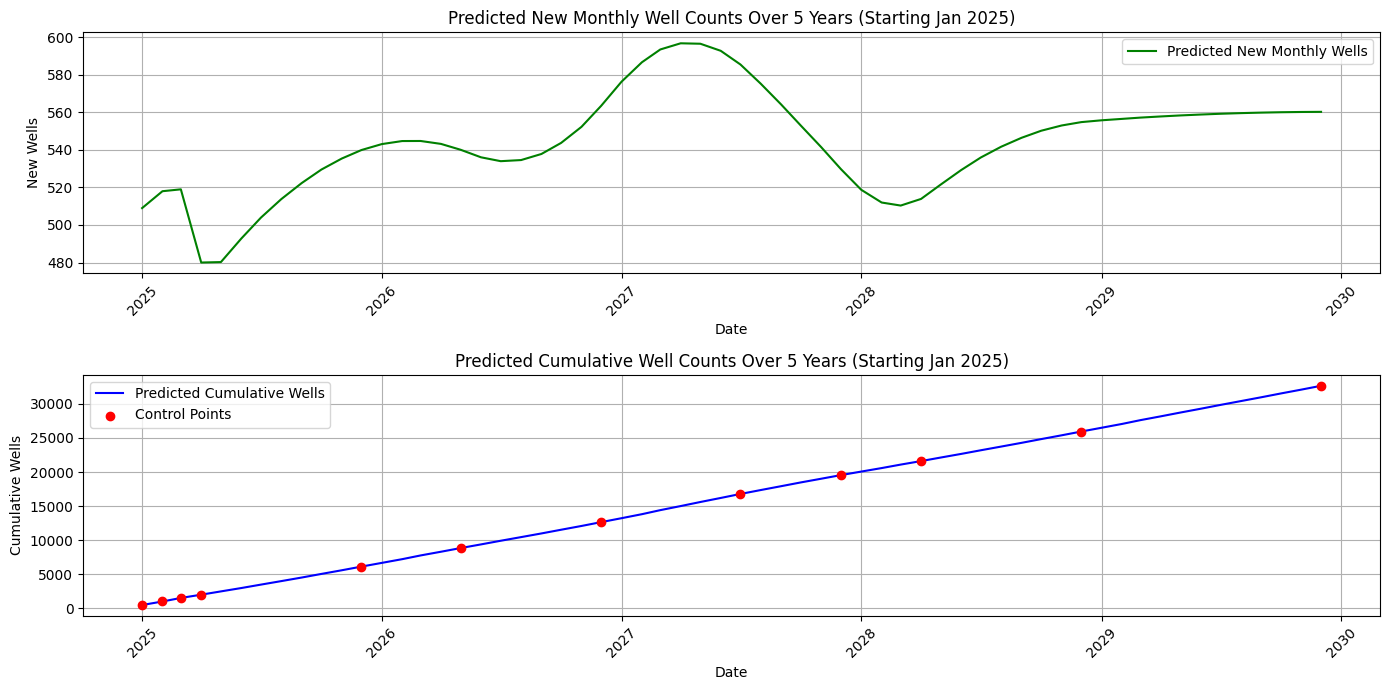

In [110]:
#@title Plot Monthly and Cummulative Wells
plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
# Use 'Date' column for plotting
plt.plot(df_results['Date'], monthly_new_wells, label='Predicted New Monthly Wells', color='green')
plt.title('Predicted New Monthly Well Counts Over 5 Years (Starting Jan 2025)')
plt.xlabel('Date')
plt.ylabel('New Wells')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45) # Rotate date labels for readability

plt.subplot(2, 1, 2)
# Use 'Date' column for plotting
plt.plot(df_results['Date'], y_predicted_cumulative, label='Predicted Cumulative Wells', color='blue')

# Map control points back to dates for plotting scatter points
control_point_dates = [dates[x] for x in final_x_control]
plt.scatter(control_point_dates, final_y_control, color='red', zorder=5, label='Control Points')

plt.title('Predicted Cumulative Well Counts Over 5 Years (Starting Jan 2025)')
plt.xlabel('Date')
plt.ylabel('Cumulative Wells')


plt.grid(True)
plt.legend()
plt.xticks(rotation=45) # Rotate date labels for readability

plt.tight_layout()
plt.show()

In [111]:
from scipy.signal import find_peaks

# Find peaks (local maxima) in monthly new wells
peaks, _ = find_peaks(monthly_new_wells)

print("\n--- Current Peaks in Predicted New Wells ---")
for month_idx in peaks:
    print(f"Month Index: {month_idx}, Date: {dates[month_idx].strftime('%Y-%m')}, New Wells: {monthly_new_wells[month_idx]:.2f}")

# Find troughs (local minima) by finding peaks in the inverted signal
troughs, _ = find_peaks(-monthly_new_wells)

print("\n--- Current Troughs in Predicted New Wells ---")
for month_idx in troughs:
    print(f"Month Index: {month_idx}, Date: {dates[month_idx].strftime('%Y-%m')}, New Wells: {monthly_new_wells[month_idx]:.2f}")


--- Current Peaks in Predicted New Wells ---
Month Index: 2, Date: 2025-03, New Wells: 519.00
Month Index: 14, Date: 2026-03, New Wells: 544.77
Month Index: 27, Date: 2027-04, New Wells: 596.82

--- Current Troughs in Predicted New Wells ---
Month Index: 3, Date: 2025-04, New Wells: 480.00
Month Index: 18, Date: 2026-07, New Wells: 534.00
Month Index: 38, Date: 2028-03, New Wells: 510.35
